Import Library

In [10]:
import pandas as pd

Import data

In [11]:
df1 = pd.read_csv('for_supervised_raw.csv')
df1 = df1.drop('Cluster_ID' , axis = 1)

df2 = pd.read_csv('unsupervised_results.csv')

Merge data

In [12]:
df_final = pd.concat([df1, df2], axis=1)
df_final.head()

,Age,Profession,Sex,Province,S_Occasion,C_Occasion,C_Frequency,S_Frequency,S_Screentime,S_Time(weekday),S_Time(weekend),S_Usage(festival),row_id,Cluster_ID
0,23-29ปี,พนักงานบริษัทเอกชน,ชาย,กรุงเทพมหานคร,Instagram,ไม่ดื่มกาแฟ Ready to drink เลย,กาแฟสดคั่วบด เช่น ร้านกาแฟสด,5-6 ครั้ง/อาทิตย์,5-6 ชม./วัน,"05.00-8.59น., 18.00-21.59น., 22.01-4.59น.","05.00-8.59น., 9.00-17.59น., 18.00-21.59น., 22....",ใช้มากกว่าปกติ,0,-1
1,23-29ปี,พนักงานบริษัทเอกชน,หญิง,กรุงเทพมหานคร,LINE,ไม่ดื่มกาแฟ Ready to drink เลย,กาแฟสดคั่วบด เช่น ร้านกาแฟสด,ทุกวัน,มากกว่า 6 ชม./วัน,"18.00-21.59น., 22.01-4.59น.","9.00-17.59น., 18.00-21.59น., 22.01-4.59น.",ใช้มากกว่าปกติ,1,1
2,23-29ปี,พนักงานบริษัทเอกชน,หญิง,กรุงเทพมหานคร,LINE,ดื่มให้ไม่ง่วงในวันที่ทำงานดึก,กาแฟสดคั่วบด เช่น ร้านกาแฟสด,ทุกวัน,3-4 ชม./วัน,"9.00-17.59น., 18.00-21.59น., 22.01-4.59น.","9.00-17.59น., 18.00-21.59น., 22.01-4.59น.",ใช้น้อยกว่าปกติ,2,0
3,30-39ปี,ฟรีแลนซ์/อาชีพอิสระ,ชาย,กรุงเทพมหานคร,LINE,ไม่ดื่มกาแฟ Ready to drink เลย,แคปซูลกาแฟ,ทุกวัน,5-6 ชม./วัน,18.00-21.59น.,18.00-21.59น.,ใช้เท่าเดิม,3,1
4,23-29ปี,พนักงานบริษัทเอกชน,ชาย,กรุงเทพมหานคร,Facebook,ไม่ดื่มกาแฟ Ready to drink เลย,กาแฟสดคั่วบด เช่น ร้านกาแฟสด,ทุกวัน,3-4 ชม./วัน,"9.00-17.59น., 18.00-21.59น.","9.00-17.59น., 18.00-21.59น., 22.01-4.59น.",ใช้เท่าเดิม,4,1


In [13]:
# Export ไฟล์ CSV
# df_final.to_csv('eda_file.csv', index=False)
# print("Export Success!")

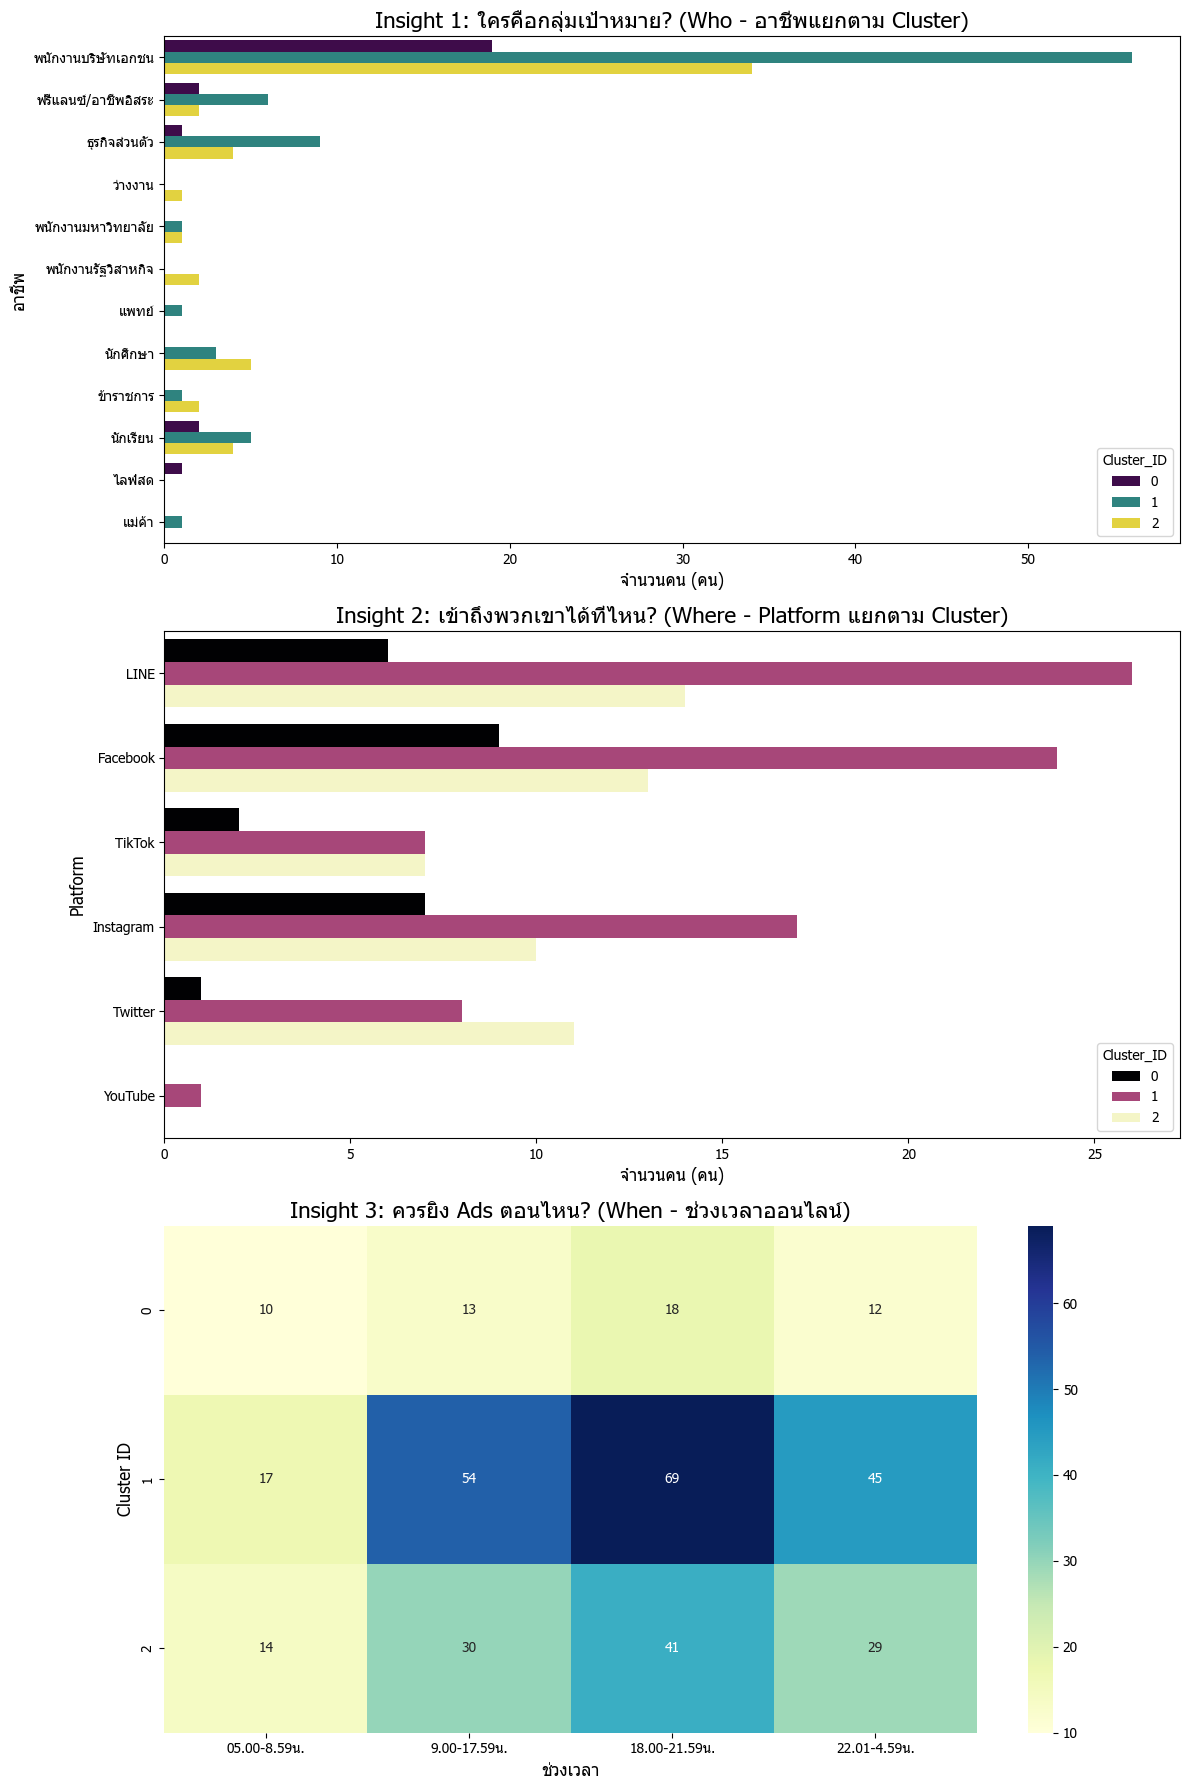

--- สรุป Insight คร่าวๆ ---
Cluster 0: ส่วนใหญ่เป็น 'พนักงานบริษัทเอกชน' เล่น 'Facebook' เป็นหลัก
Cluster 1: ส่วนใหญ่เป็น 'พนักงานบริษัทเอกชน' เล่น 'LINE' เป็นหลัก
Cluster 2: ส่วนใหญ่เป็น 'พนักงานบริษัทเอกชน' เล่น 'LINE' เป็นหลัก


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Tahoma' 
plt.rcParams['axes.unicode_minus'] = False

df_plot = df_final[df_final['Cluster_ID'] != -1].copy()

# --- 3. เตรียมข้อมูลสำหรับ Heatmap (กราฟ "When") ---
# เนื่องจากเวลาเป็น String ที่คั่นด้วย comma เราต้องแยก (Explode) ออกมา
time_slots = df_plot['S_Time(weekday)'].str.split(', ').explode()
time_df = pd.DataFrame({
    'Cluster_ID': df_plot.loc[time_slots.index, 'Cluster_ID'],
    'Time_Slot': time_slots.str.strip()
})
# เรียงลำดับเวลาให้ถูกต้อง
time_order = ['05.00-8.59น.', '9.00-17.59น.', '18.00-21.59น.', '22.01-4.59น.']
time_matrix = pd.crosstab(time_df['Cluster_ID'], time_df['Time_Slot'])[time_order]

# --- 4. เริ่มการพล็อต 3 กราฟยุทธศาสตร์ ---
fig, ax = plt.subplots(3, 1, figsize=(12, 18))

# กราฟที่ 1: Who (อาชีพแยกตาม Cluster)
sns.countplot(data=df_plot, y='Profession', hue='Cluster_ID', palette='viridis', ax=ax[0])
ax[0].set_title('Insight 1: ใครคือกลุ่มเป้าหมาย? (Who - อาชีพแยกตาม Cluster)', fontsize=16)
ax[0].set_xlabel('จำนวนคน (คน)', fontsize=12)
ax[0].set_ylabel('อาชีพ', fontsize=12)

# กราฟที่ 2: Where (Social Media แยกตาม Cluster)
sns.countplot(data=df_plot, y='S_Occasion', hue='Cluster_ID', palette='magma', ax=ax[1])
ax[1].set_title('Insight 2: เข้าถึงพวกเขาได้ที่ไหน? (Where - Platform แยกตาม Cluster)', fontsize=16)
ax[1].set_xlabel('จำนวนคน (คน)', fontsize=12)
ax[1].set_ylabel('Platform', fontsize=12)

# กราฟที่ 3: When (ช่วงเวลาออนไลน์แยกตาม Cluster)
sns.heatmap(time_matrix, annot=True, cmap='YlGnBu', fmt='d', ax=ax[2])
ax[2].set_title('Insight 3: ควรยิง Ads ตอนไหน? (When - ช่วงเวลาออนไลน์)', fontsize=16)
ax[2].set_xlabel('ช่วงเวลา', fontsize=12)
ax[2].set_ylabel('Cluster ID', fontsize=12)

plt.tight_layout()
plt.show()

# พิมพ์สรุปสั้นๆ
print("--- สรุป Insight คร่าวๆ ---")
for c in sorted(df_plot['Cluster_ID'].unique()):
    top_prof = df_plot[df_plot['Cluster_ID'] == c]['Profession'].mode()[0]
    top_plat = df_plot[df_plot['Cluster_ID'] == c]['S_Occasion'].mode()[0]
    print(f"Cluster {c}: ส่วนใหญ่เป็น '{top_prof}' เล่น '{top_plat}' เป็นหลัก")

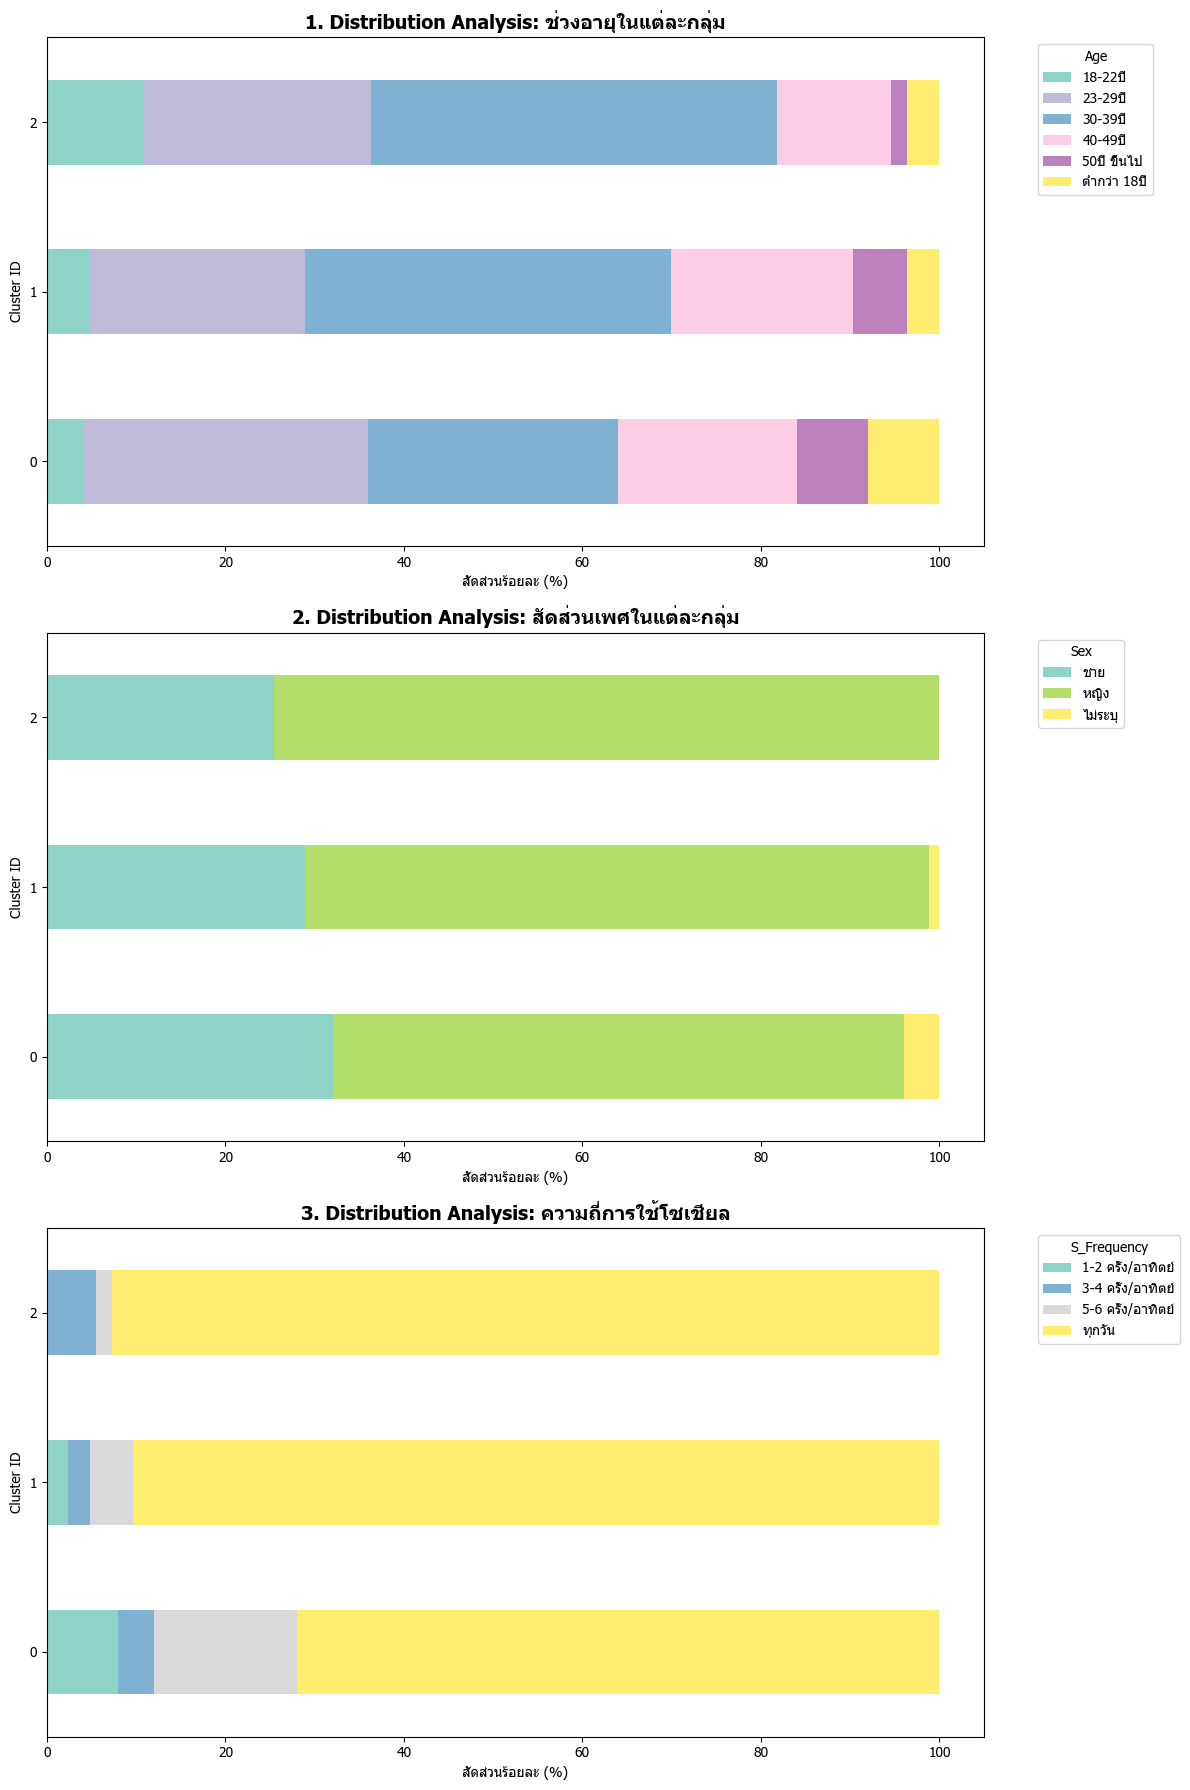

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. ฟังก์ชันสำหรับสร้างกราฟ Distribution แบบร้อยละ
def plot_distribution(df_final, col_name, title, ax):
    # คำนวณสัดส่วนร้อยละ
    dist_data = df_plot.groupby(['Cluster_ID', col_name]).size().unstack(fill_value=0)
    dist_pct = dist_data.div(dist_data.sum(axis=1), axis=0) * 100
    
    # พล็อตกราฟ
    dist_pct.plot(kind='barh', stacked=True, ax=ax, colormap='Set3')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('สัดส่วนร้อยละ (%)')
    ax.set_ylabel('Cluster ID')
    ax.legend(title=col_name, bbox_to_anchor=(1.05, 1), loc='upper left')

# 3. สร้างกราฟวิเคราะห์ 3 ประเด็นสำคัญ
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

plot_distribution(df_plot, 'Age', '1. Distribution Analysis: ช่วงอายุในแต่ละกลุ่ม', axes[0])
plot_distribution(df_plot, 'Sex', '2. Distribution Analysis: สัดส่วนเพศในแต่ละกลุ่ม', axes[1])
plot_distribution(df_plot, 'S_Frequency', '3. Distribution Analysis: ความถี่การใช้โซเชียล', axes[2])

plt.tight_layout()
plt.show()

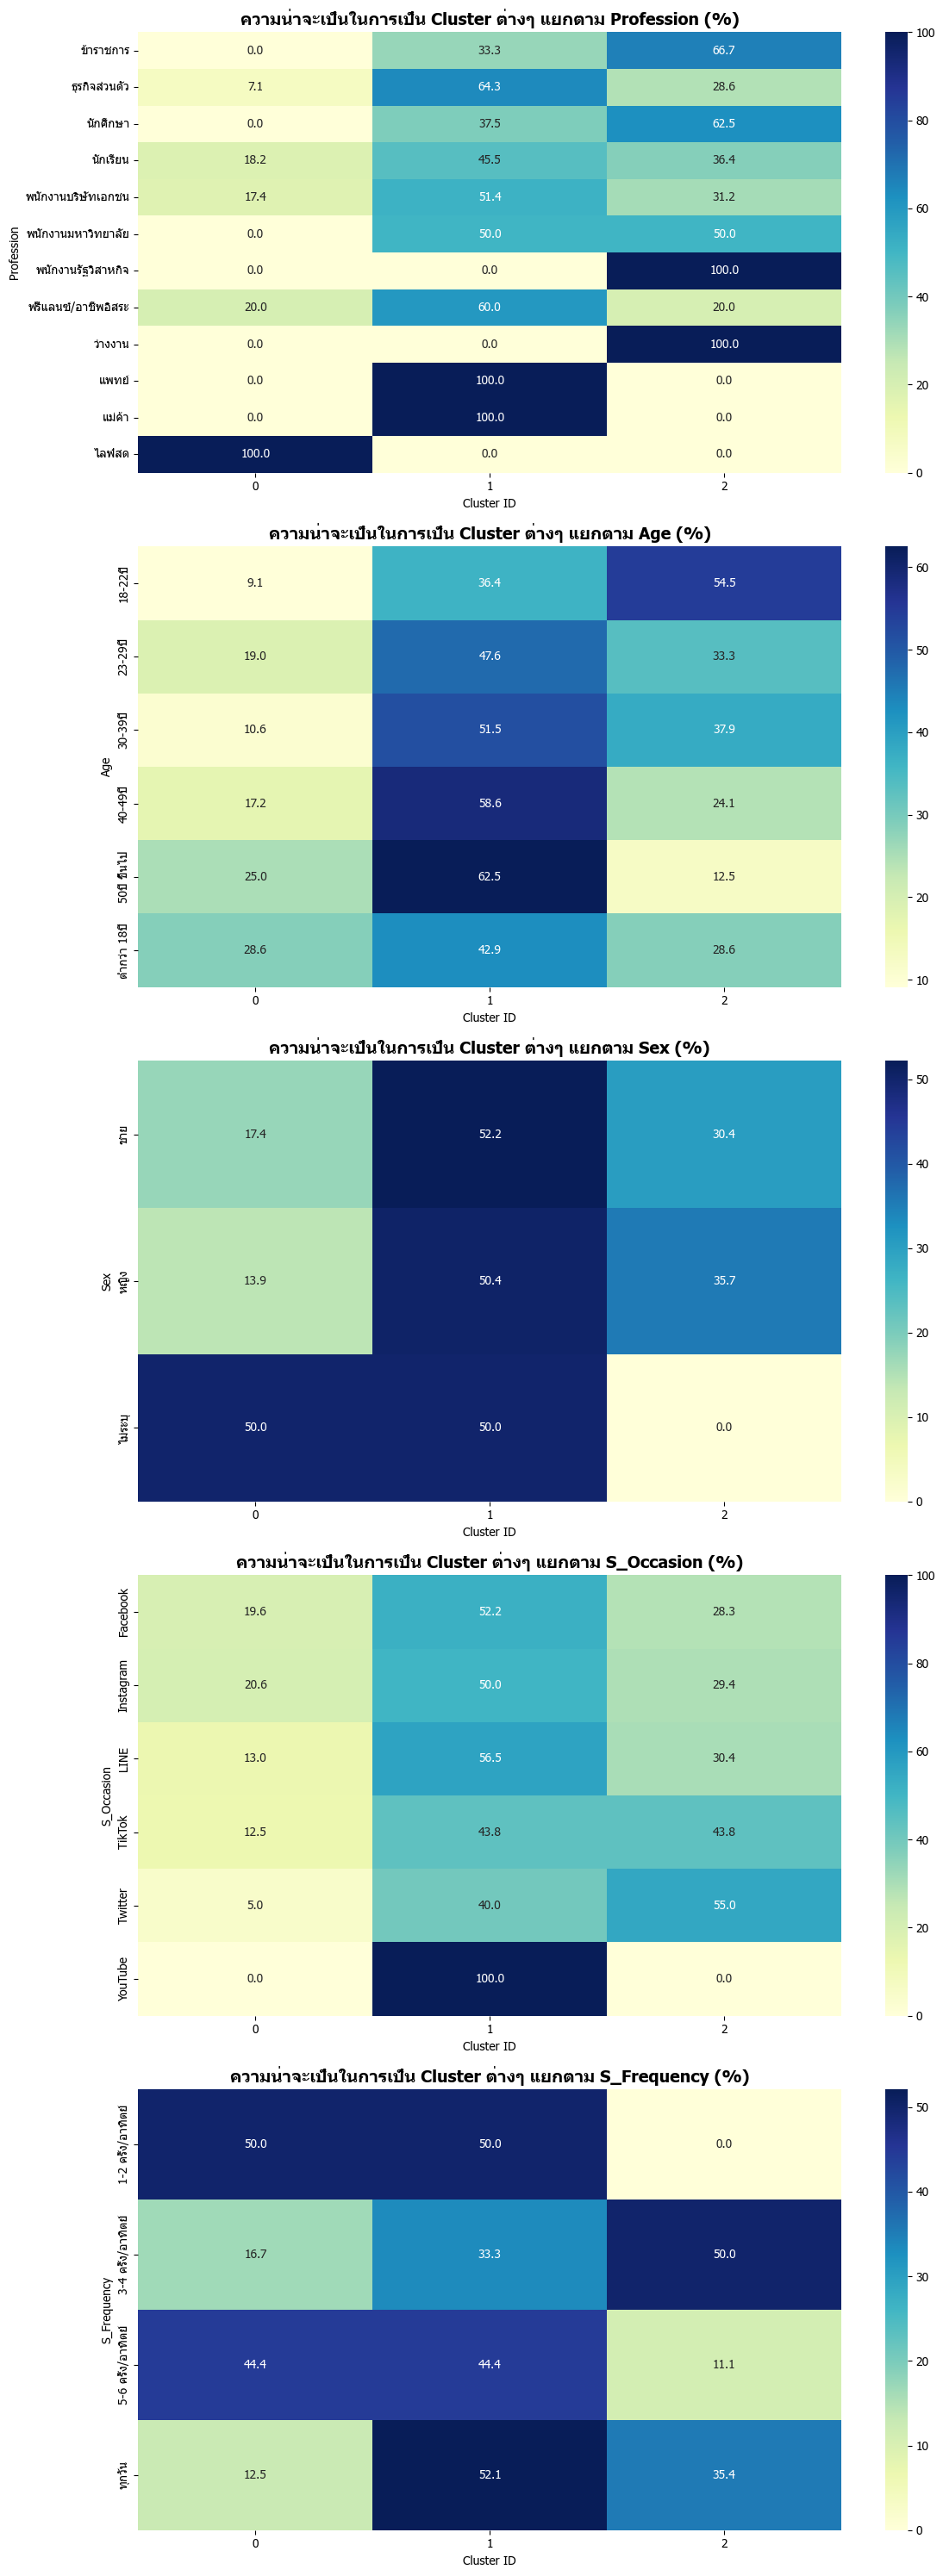

--- ตัวอย่าง Insight ---
คนที่เป็นกลุ่ม 'ทุกวัน' มีโอกาสสูงที่สุดที่จะอยู่ใน Cluster 1


In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# 2. โหลดข้อมูล (อิงจากไฟล์ล่าสุดของคุณ)

# 3. เลือกปัจจัยที่ต้องการดูความสัมพันธ์กับ Cluster_ID
# คุณสามารถเพิ่มหรือลดชื่อคอลัมน์ในลิสต์นี้ได้ตามต้องการ
demographic_cols = ['Profession', 'Age', 'Sex', 'S_Occasion', 'S_Frequency']

# 4. สร้างกราฟ Heatmap แยกตามปัจจัยต่างๆ
fig, axes = plt.subplots(len(demographic_cols), 1, figsize=(12, 6 * len(demographic_cols)))

for i, col in enumerate(demographic_cols):
    # สร้าง Cross-tabulation และแปลงเป็นร้อยละตามแถว (ลักษณะประชากร)
    # เช่น ในบรรดา "พนักงานบริษัท" ทั้งหมด แบ่งเป็น Cluster ไหนกี่ %
    ct = pd.crosstab(df_plot[col], df_plot['Cluster_ID'], normalize='index') * 100
    
    # พล็อต Heatmap
    sns.heatmap(ct, annot=True, cmap='YlGnBu', fmt='.1f', ax=axes[i])
    axes[i].set_title(f'ความน่าจะเป็นในการเป็น Cluster ต่างๆ แยกตาม {col} (%)', fontsize=14, fontweight='bold')
    axes[i].set_ylabel(col)
    axes[i].set_xlabel('Cluster ID')

plt.tight_layout()
plt.show()

# 5. สรุปผลตัวอย่างหนึ่งจุด (Insight Extraction)
top_match = ct.stack().idxmax()
print(f"--- ตัวอย่าง Insight ---")
print(f"คนที่เป็นกลุ่ม '{top_match[0]}' มีโอกาสสูงที่สุดที่จะอยู่ใน Cluster {top_match[1]}")